# Project: Cookie-cats A/B test Analysis

Using a Kaggle dataset: https://www.kaggle.com/datasets/zahrazolghadr/ab-test-cookie-cats

### Research Question

> **Does moving the first gate from level 30 to level 40 affect player retention and engagement?**

## Business context

Cookie Cats is a mobile puzzle game where players progress through levels. To continue playing, players eventually encounter gates that restrict their progression.

The product team is considering moving the first gate from **level 30 to level 40**. The idea is that allowing players to progress further before encountering the first gate may improve their experience and encourage them to stay engaged with the game.

However, changing the gate position could also have an unintended negative effect. For example, the change might affect players' engagement or reduce the likelihood that they return to the game.

To evaluate the impact of this change, an A/B test was conducted:

* **Control group (gate_30)** — players encountered the first gate at level 30.
* **Treatment group (gate_40)** — players encountered the first gate at level 40.

### Business Question

> **Should Cookie Cats move the first gate from level 30 to level 40?**

To answer this question, we will compare player retention and engagement between the two experimental groups and determine whether the observed differences are statistically and practically meaningful.

### Success Criteria

The primary outcome of the experiment will be **7-day retention (D7 retention)**, as it provides an indication of whether the change has a sustained effect on player engagement.

We will also examine:

* **1-day retention (D1)** as a secondary retention metric;
* **number of game rounds played** as an engagement metric.

The final recommendation will consider not only statistical significance, but also the **size and uncertainty of the observed effect** and whether the results provide sufficient evidence to support a product decision.


## Experiment Design

The experiment compares two versions of the game that differ only in the position of the first progression gate.

### Experimental Population

The experimental population consists of players who participated in the Cookie Cats A/B test.

Each player was assigned to one of two experimental groups:

* **Control (gate_30)** — the first gate was placed at level 30.
* **Treatment (gate_40)** — the first gate was placed at level 40.

The **unit of randomization is the player**, meaning that each player belongs to exactly one experimental group.

This is important because the outcomes of interest — retention and number of game rounds — are measured at the player level.

### Randomized Experiment

The dataset represents a randomized controlled experiment. Players were assigned to the control or treatment group before their behavior was observed.

The experimental structure can therefore be represented as:

```text
                    Players
                       │
                Random assignment
                       │
              ┌────────┴────────┐
              │                 │
              ▼                 ▼
          gate_30           gate_40
          Control           Treatment
              │                 │
              ▼                 ▼
        Player behavior    Player behavior
              │                 │
              └────────┬────────┘
                       ▼
                  Compare outcomes
```

Randomization is essential because it allows us to attribute differences in outcomes between the groups to the change in gate position, assuming that the experiment was implemented correctly.

### Expected Group Allocation

The experiment is expected to have an approximately **50/50 allocation** between the control and treatment groups.

Before comparing retention or engagement, we will therefore check whether the observed group sizes are consistent with this expected allocation.

This is known as a **Sample Ratio Mismatch (SRM) check**. A substantial deviation from the expected allocation may indicate an issue with the experiment or data collection process and could undermine the validity of subsequent comparisons.

### Metrics

The analysis will focus on three outcome metrics.

**Primary metric — D7 retention**

`retention_7` indicates whether a player returned to the game seven days after installation.

This will be the primary metric used for the final product decision because it captures longer-term player retention.

**Secondary metric — D1 retention**

`retention_1` indicates whether a player returned to the game one day after installation.

D1 retention provides an earlier measure of player engagement and can help determine whether the treatment has an immediate effect.

**Engagement metric — Game rounds**

`sum_gamerounds` represents the total number of game rounds played by each player during the observed period.

This metric will be used to assess whether moving the gate affects the amount of gameplay, providing additional context for the retention results.

### Statistical Hypotheses

The primary hypothesis concerns D7 retention.

**Null hypothesis (H₀):**

> There is no difference in D7 retention between players exposed to `gate_30` and `gate_40`.

**Alternative hypothesis (H₁):**

> D7 retention differs between players exposed to `gate_30` and `gate_40`.

A **two-sided hypothesis test** will be used because the experiment is intended to detect both potential improvements and deteriorations in retention.

### Analysis Strategy

The analysis will proceed in the following order:

1. Verify the structure and quality of the experimental data.
2. Check whether the observed group allocation is consistent with the expected 50/50 split.
3. Compare D7 retention between the control and treatment groups.
4. Estimate the absolute and relative treatment effect.
5. Calculate a 95% confidence interval for the treatment effect.
6. Assess statistical significance.
7. Repeat the analysis for D1 retention as a secondary metric.
8. Compare engagement using `sum_gamerounds`.
9. Perform additional robustness checks, including bootstrap estimation.
10. Translate the statistical results into a product recommendation.

The primary conclusion will be based on **D7 retention**, while D1 retention and game rounds will be used as supporting evidence rather than as independent reasons to declare the treatment successful.


## Required Libraries Import

In [1]:
import numpy as np
import pandas as pd

import scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
    test_proportions_2indep,
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
DATA_PATH = "data/cookie_cats.txt"

df = pd.read_csv(
    DATA_PATH,
    dtype={"userid": "int64", "version": "category", "sum_gamerounds": "int64"},
    true_values=["True"],
    false_values=["False"],
)

print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.head()

Rows: 90,189  Columns: 5


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Data Quality Checks

In [4]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

print("Column types and memory")
df.info()

print("\nMissing values per column")
print(df.isna().sum())


Shape: 90,189 rows x 5 columns

Column types and memory
<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   userid          90189 non-null  int64   
 1   version         90189 non-null  category
 2   sum_gamerounds  90189 non-null  int64   
 3   retention_1     90189 non-null  bool    
 4   retention_7     90189 non-null  bool    
dtypes: bool(2), category(1), int64(2)
memory usage: 1.6 MB

Missing values per column
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [6]:
print("\nDuplicates")
print(f"Fully duplicated rows: {df.duplicated().sum():,}")
print(f"Duplicated userid:     {df['userid'].duplicated().sum():,}")

print("\nuserid uniqueness")
n_unique = df["userid"].nunique()
print(f"Unique userid: {n_unique:,} of {len(df):,} rows")
print(f"One row per player: {n_unique == len(df)}")



Duplicates
Fully duplicated rows: 0
Duplicated userid:     0

userid uniqueness
Unique userid: 90,189 of 90,189 rows
One row per player: True


In [7]:
print("\nsum_gamerounds range")
print(df["sum_gamerounds"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"\nNegative values: {(df['sum_gamerounds'] < 0).sum():,}")
print(f"Players with 0 rounds: {(df['sum_gamerounds'] == 0).sum():,} "
      f"({(df['sum_gamerounds'] == 0).mean():.2%})")

print("\nCategorical values")
print(df["version"].value_counts(dropna=False))


sum_gamerounds range
count   90189.0000
mean       51.8725
std       195.0509
min         0.0000
25%         5.0000
50%        16.0000
75%        51.0000
95%       221.0000
99%       493.0000
max     49854.0000
Name: sum_gamerounds, dtype: float64

Negative values: 0
Players with 0 rounds: 3,994 (4.43%)

Categorical values
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


According to this audit the dataset contains no ambiguous rows that require future investigations. Tht means no additional cleaning pipeline is needed.

## Sample Ratio Mismatch (SRM) Check

Before comparing any outcome metrics, we verify that the observed group allocation matches the intended **50/50 split**.

If the realised allocation deviates from the expected one by more than chance, this signals a problem in the randomisation or data collection process (for example, a broken assignment rule or players lost from one variant). In that case any difference in retention could be caused by the flawed assignment rather than by the gate position, so the experiment would not be trustworthy.

**Hypotheses**

* **H₀:** players were allocated to `gate_30` and `gate_40` with equal probability (50/50).
* **H₁:** the allocation probability differs from 50/50.

**Test:** a chi-square goodness-of-fit test on the observed group counts against the expected equal split, cross-checked with an exact binomial test.

**Decision rule:** SRM checks use a much stricter threshold than ordinary metric tests, conventionally **p < 0.001**. The test is run on the full sample, so it is sensitive enough to flag trivial imbalances; the strict threshold keeps us from rejecting a valid experiment because of a fraction-of-a-percent difference in group sizes.

In [8]:
SRM_ALPHA = 0.001

group_counts = df["version"].value_counts().sort_index()
n_total = int(group_counts.sum())
expected = np.full(len(group_counts), n_total / len(group_counts))

chi2_stat, chi2_p = st.chisquare(f_obs=group_counts.to_numpy(), f_exp=expected)
binom_p = st.binomtest(int(group_counts.iloc[0]), n_total, p=0.5).pvalue

srm_table = pd.DataFrame({
    "observed": group_counts.astype(int),
    "expected": expected,
    "observed_share": group_counts / n_total,
    "diff_vs_expected": group_counts - expected,
})

print(srm_table.to_string())
print(f"\nTotal players: {n_total:,}")
print(f"Chi-square: statistic = {chi2_stat:.4f}, p-value = {chi2_p:.4f}")
print(f"Exact binomial p-value: {binom_p:.4f}")
print(f"\nSRM detected at alpha = {SRM_ALPHA}: {chi2_p < SRM_ALPHA}")

         observed   expected  observed_share  diff_vs_expected
version                                                       
gate_30     44700 45094.5000          0.4956         -394.5000
gate_40     45489 45094.5000          0.5044          394.5000

Total players: 90,189
Chi-square: statistic = 6.9024, p-value = 0.0086
Exact binomial p-value: 0.0087

SRM detected at alpha = 0.001: False


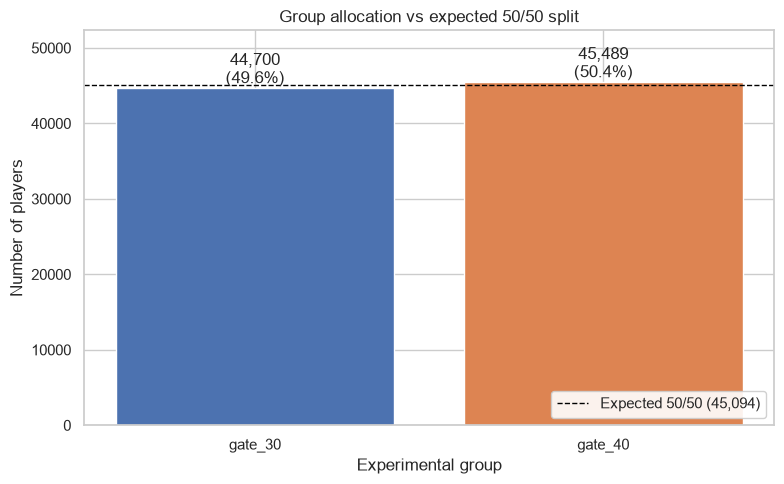

In [9]:
fig, ax = plt.subplots()

ax.bar(group_counts.index.astype(str), group_counts.to_numpy(), color=["#4C72B0", "#DD8452"])
ax.axhline(n_total / len(group_counts), color="black", linestyle="--", linewidth=1,
           label=f"Expected 50/50 ({n_total / len(group_counts):,.0f})")

for x, count in enumerate(group_counts):
    ax.text(x, count, f"{count:,}\n({count / n_total:.1%})", ha="center", va="bottom")

ax.set_title("Group allocation vs expected 50/50 split")
ax.set_xlabel("Experimental group")
ax.set_ylabel("Number of players")
ax.set_ylim(0, group_counts.max() * 1.15)
ax.legend(loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()

The observed allocation was 49.56% for gate_30 and 50.44% for gate_40, compared with the expected 50/50 split. The chi-square test produced a p-value of 0.0086. Using a conservative SRM significance threshold of α = 0.001, the result does not indicate a sample ratio mismatch. Although the allocation deviates slightly from 50/50, the magnitude of the deviation is small (0.44 percentage points).
